In [25]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import math

from tensorflow import keras
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model


In [26]:
#loading and preprocessing the image
def load_and_preprocessing(image_loc):
    img = load_img(image_loc)
    img = img_to_array(img)
    img = preprocess_input(img)

    img = np.expand_dims(img, axis=0)
    return img

print('img processing function defined successfully')


img processing function defined successfully


In [ ]:
#deprocessing function
def deprocess(img):
    # ensure we operate in float to avoid in-place uint8 casting errors
    img = np.array(img, dtype=np.float32, copy=True)

    if img.ndim == 4:
        img = np.squeeze(img, axis=0)

    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68
    img = img[:, :, ::-1]

    img = np.clip(img, 0, 255).astype('uint8')
    return img

print('deprocessing function defined successfully')

def print_img(img):
    if len(img.shape) == 4: 
        img = np.squeeze(img, axis=0)

    img = deprocess(img)
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img)
    plt.show()
    return


deprocessing function defined successfully


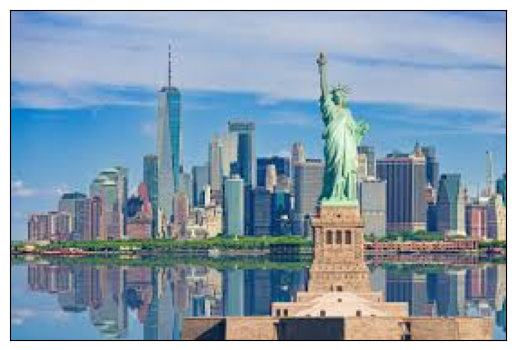

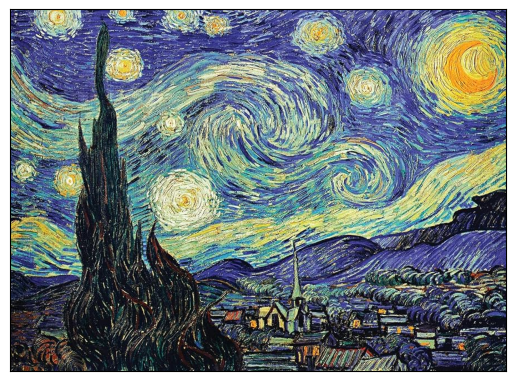

In [28]:
content_img = load_and_preprocessing('newyork.jpg')
display_img = np.squeeze(content_img, axis=0)
print_img(display_img)

style_img = load_and_preprocessing('starrynights.jpg')
display_img = np.squeeze(style_img, axis=0)
print_img(display_img)


In [29]:
#model selection -- pretrained imagenet weights, without the top layer fro transfer learning 
model = VGG19(
    include_top=False,
    weights='imagenet'
)
model.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
#content model
content_layer = 'block5_conv2'

content_model = Model(
    inputs = model.input,
    outputs = model.get_layer(content_layer).output
)
content_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 15,304,768 (58.38 MB)

 Trainable params: 15,304,768 (58.38 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
#style model
style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

style_models = [Model(
    inputs = model.input,
    outputs = model.get_layer(layer).output
) for layer in style_layers]

style_models[0].summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,792 (7.00 KB)

 Trainable params: 1,792 (7.00 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
#content loss function
def content_loss(content, generated):
    a_cont = content_model(content)
    a_gen = content_model(generated)
    loss = tf.reduce_mean(tf.square(a_cont - a_gen))
    return loss

#gram matrix for style loss
def gram_matrix(A):
    channels = int(A.shape[-1])
    a = tf.reshape(A, [-1, channels])
    n = tf.shape(a)[0]
    gram = tf.matmul(a, a, transpose_a=True)
    return gram / tf.cast(n, tf.float32)

# weight per style layer (scalar)
weight_per_style_layer = 1.0 / len(style_layers)


In [33]:
def style_cost(style, generated):
    loss = 0.0
    weight = weight_per_style_layer
    for style_layer in style_models:
        a_style = style_layer(style)
        a_gen = style_layer(generated)
        gram_style = gram_matrix(a_style)
        gram_gen = gram_matrix(a_gen)
        loss += weight * tf.reduce_mean(tf.square(gram_style - gram_gen))
    return loss


In [34]:
# Duplicate/incorrect cell cleared — content_loss already implemented above
pass


In [37]:
generated_imgs = []
import time

def training_loop(content_path, style_path, iterations = 50, a = 10, b = 1000):
    content_img = load_and_preprocessing(content_path)
    style_img =  load_and_preprocessing(style_path)
    generated_var = tf.Variable(content_img, dtype=tf.float32)

    optimizer = tf.optimizers.Adam(learning_rate= 0.7)

    best_cost = math.inf
    best_img = None

    history = []

    for i in range(iterations):
        start_time_cpu = time.process_time()
        start_time_wall = time.time()
        with tf.GradientTape() as tape:
            c_loss = content_loss(content_img, generated_var)
            s_loss = style_cost(style_img, generated_var)
            total_loss = a * c_loss + b * s_loss

        grad = tape.gradient(total_loss, generated_var)
        optimizer.apply_gradients([(grad, generated_var)])

        end_time_cpu = time.process_time()
        end_time_wall = time.time()
        cpu_time = end_time_cpu - start_time_cpu
        wall_time = end_time_wall - start_time_wall

        if total_loss < best_cost:
            best_cost = total_loss
            best_img = deprocess(np.squeeze(generated_var.numpy(), axis=0))

        print("CPU times: user {} µs, sys: {} ns, total: {} µs".format(
          int(cpu_time * 1e6),
          int(( end_time_cpu - start_time_cpu) * 1e9),
          int((end_time_cpu - start_time_cpu + 1e-6) * 1e6))
             )

        print("Wall time: {:.2f} µs".format(wall_time * 1e6))
        print("Iteration :{}".format(i))
        print('Total Loss {:e}.'.format(total_loss))

        # save a deprocessed snapshot for this iteration
        history.append(deprocess(np.squeeze(generated_var.numpy(), axis=0)))

    return best_img, history


In [42]:
best_img, history = training_loop('newyork.jpg', 'starrynights.jpg', iterations=50, a=10, b=1000)
final_img = best_img

CPU times: user 94859375 µs, sys: 94859375000 ns, total: 94859376 µs
Wall time: 13695934.53 µs
Iteration :0
Total Loss 6.221002e+13.
CPU times: user 93234375 µs, sys: 93234375000 ns, total: 93234376 µs
Wall time: 13815540.31 µs
Iteration :1
Total Loss 5.773423e+13.
CPU times: user 90984375 µs, sys: 90984375000 ns, total: 90984376 µs
Wall time: 13655411.01 µs
Iteration :2
Total Loss 5.374486e+13.
CPU times: user 92546875 µs, sys: 92546875000 ns, total: 92546876 µs
Wall time: 13303225.28 µs
Iteration :3
Total Loss 5.021719e+13.
CPU times: user 93484375 µs, sys: 93484375000 ns, total: 93484376 µs
Wall time: 13395374.06 µs
Iteration :4
Total Loss 4.703597e+13.
CPU times: user 89359375 µs, sys: 89359375000 ns, total: 89359376 µs
Wall time: 13641884.33 µs
Iteration :5
Total Loss 4.410878e+13.
CPU times: user 90890625 µs, sys: 90890625000 ns, total: 90890626 µs
Wall time: 13110656.98 µs
Iteration :6
Total Loss 4.137356e+13.
CPU times: user 91640625 µs, sys: 91640625000 ns, total: 91640626 µs


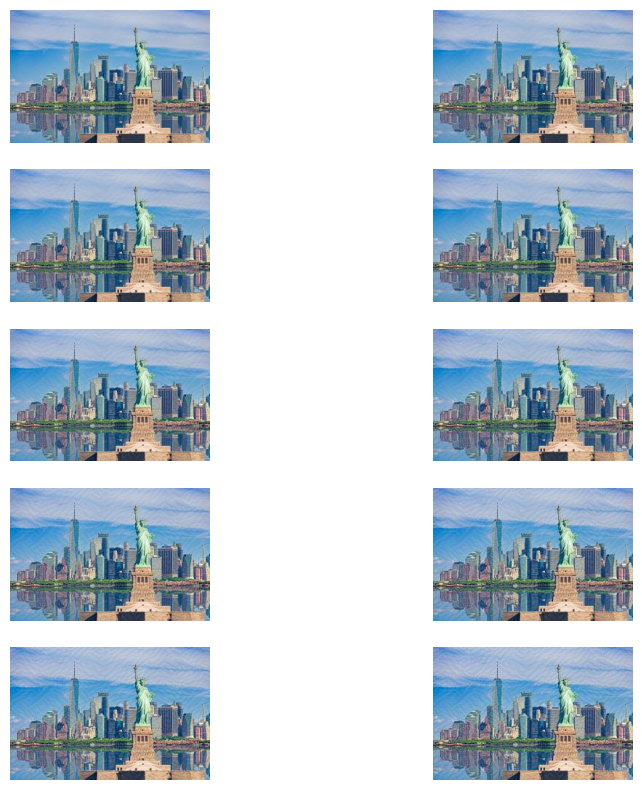

UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('uint8') with casting rule 'same_kind'

In [43]:
# Plot training snapshots and final image (safe if training wasn't run)
if 'history' not in globals() or history is None:
    print("No `history` available. Run the training cell first: best_img, history = training_loop(...)")
else:
    plt.figure(figsize=(10,10))
    n = min(10, len(history))
    for i in range(n):
        plt.subplot(5, 2, i+1)
        plt.imshow(history[i])
        plt.axis('off')
    plt.show()

if 'final_img' in globals() and final_img is not None:
    print_img(final_img)
else:
    print("No `final_img` available. It will be set after running the training cell.")
